# SciFact Dataset EDA

Разведочный анализ датасета `BEIR SciFact` для retrieval-исследования SciGuide: корпус документов, запросы, разметка релевантности, нарезка текста и графовые сущности.

Зависимости для запуска в notebook kernel:

```python
%pip install pandas matplotlib langchain-text-splitters
```


## Подготовка окружения


In [1]:
from __future__ import annotations

import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 120)

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "notebooks":
    NOTEBOOK_DIR = Path.cwd() / "notebooks"

PROJECT_ROOT = NOTEBOOK_DIR.parent
PACKAGES_DIR = PROJECT_ROOT / "src" / "packages"
DATASET_DIR = NOTEBOOK_DIR / "data" / "scifact"

if str(PACKAGES_DIR) not in sys.path:
    sys.path.insert(0, str(PACKAGES_DIR))

if not DATASET_DIR.exists():
    raise FileNotFoundError(
        f"Dataset directory was not found: {DATASET_DIR}. "
        "Place BEIR SciFact files in notebooks/data/scifact."
    )

from sciguide_pipeline import SourceDocument
from sciguide_pipeline.infrastructure.processing import (
    DeterministicEntityExtractor,
    LangChainTextChunker,
)


## Загрузка данных


In [2]:
def load_jsonl(path: Path) -> list[dict]:
    with path.open(encoding="utf-8") as file:
        return [json.loads(line) for line in file]


def load_qrels(path: Path, split: str) -> pd.DataFrame:
    return (
        pd.read_csv(path, sep="	")
        .rename(
            columns={
                "query-id": "query_id",
                "corpus-id": "corpus_id",
                "score": "relevance",
            }
        )
        .assign(split=split)
    )


corpus = pd.DataFrame(load_jsonl(DATASET_DIR / "corpus.jsonl"))
queries = pd.DataFrame(load_jsonl(DATASET_DIR / "queries.jsonl"))
qrels = pd.concat(
    [
        load_qrels(DATASET_DIR / "qrels" / "train.tsv", "train"),
        load_qrels(DATASET_DIR / "qrels" / "test.tsv", "test"),
    ],
    ignore_index=True,
)

corpus["title_words"] = corpus["title"].fillna("").str.split().str.len()
corpus["text_words"] = corpus["text"].fillna("").str.split().str.len()
queries["query_words"] = queries["text"].fillna("").str.split().str.len()
qrels_per_query = qrels.groupby(["split", "query_id"]).size().rename("relevant_docs")

corpus.head(3)


,_id,title,text,metadata,title_words,text_words
0,4983,Microstructural development of human newborn cerebral white matter assessed in vivo by diffusion tensor magnetic res...,Alterations of the architecture of cerebral white matter in the developing human brain can affect cortical developme...,{},17,278
1,5836,Induction of myelodysplasia by myeloid-derived suppressor cells.,Myelodysplastic syndromes (MDS) are age-dependent stem cell malignancies that share biological features of activated...,{},7,201
2,7912,"BC1 RNA, the transcript from a master gene for ID element amplification, is able to prime its own reverse transcript...","ID elements are short interspersed elements (SINEs) found in high copy number in many rodent genomes. BC1 RNA, an ID...",{},20,180


## Общий профиль датасета


In [3]:
overview = pd.DataFrame(
    {
        "metric": [
            "documents_in_corpus",
            "queries_total",
            "qrels_rows",
            "queries_with_qrels",
            "empty_titles",
            "empty_texts",
        ],
        "value": [
            len(corpus),
            len(queries),
            len(qrels),
            qrels["query_id"].nunique(),
            int(corpus["title"].fillna("").str.strip().eq("").sum()),
            int(corpus["text"].fillna("").str.strip().eq("").sum()),
        ],
    }
)

length_summary = pd.DataFrame(
    {
        "object": ["document_title", "document_text", "query_text", "relevant_docs_per_query"],
        "mean": [
            corpus["title_words"].mean(),
            corpus["text_words"].mean(),
            queries["query_words"].mean(),
            qrels_per_query.mean(),
        ],
        "median": [
            corpus["title_words"].median(),
            corpus["text_words"].median(),
            queries["query_words"].median(),
            qrels_per_query.median(),
        ],
        "p90": [
            corpus["title_words"].quantile(0.9),
            corpus["text_words"].quantile(0.9),
            queries["query_words"].quantile(0.9),
            qrels_per_query.quantile(0.9),
        ],
        "max": [
            corpus["title_words"].max(),
            corpus["text_words"].max(),
            queries["query_words"].max(),
            qrels_per_query.max(),
        ],
    }
).round(2)

qrels_by_split = (
    qrels.groupby("split")
    .agg(
        rows=("query_id", "size"),
        queries=("query_id", "nunique"),
        documents=("corpus_id", "nunique"),
        mean_relevant_docs=("query_id", lambda value: value.value_counts().mean()),
    )
    .round(2)
    .reset_index()
)

display(overview)
display(length_summary)
display(qrels_by_split)


,metric,value
0,documents_in_corpus,5183
1,queries_total,1109
2,qrels_rows,1258
3,queries_with_qrels,1109
4,empty_titles,0
5,empty_texts,0


,object,mean,median,p90,max
0,document_title,12.82,12.0,19.0,40
1,document_text,201.81,192.0,295.0,1524
2,query_text,12.38,12.0,19.0,39
3,relevant_docs_per_query,1.13,1.0,1.0,5


,split,rows,queries,documents,mean_relevant_docs
0,test,339,300,283,1.13
1,train,919,809,565,1.14


## Распределения длин


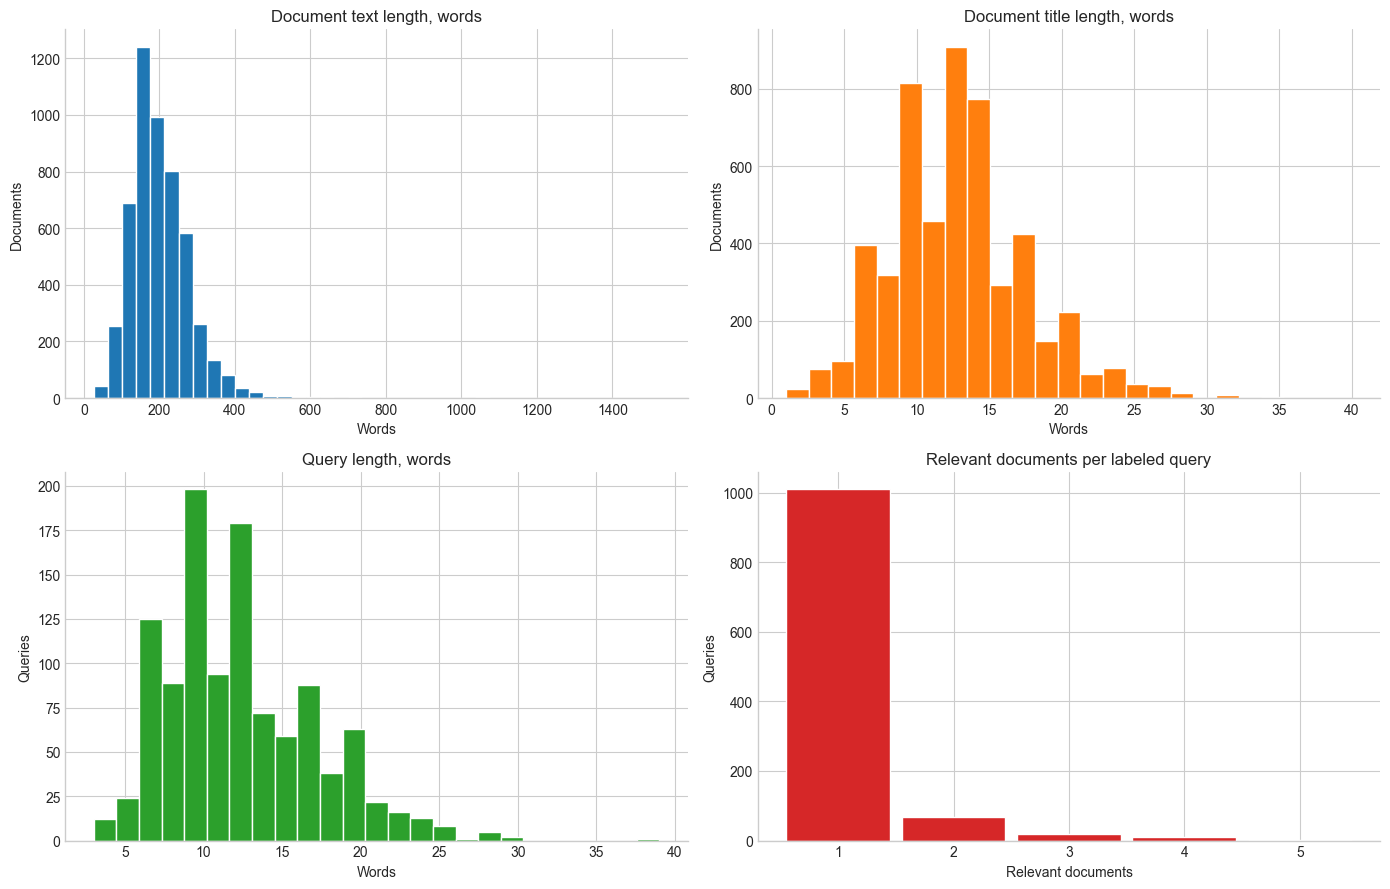

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].hist(corpus["text_words"], bins=40, color="#1f77b4", edgecolor="white")
axes[0, 0].set_title("Document text length, words")
axes[0, 0].set_xlabel("Words")
axes[0, 0].set_ylabel("Documents")

axes[0, 1].hist(corpus["title_words"], bins=25, color="#ff7f0e", edgecolor="white")
axes[0, 1].set_title("Document title length, words")
axes[0, 1].set_xlabel("Words")
axes[0, 1].set_ylabel("Documents")

axes[1, 0].hist(queries["query_words"], bins=25, color="#2ca02c", edgecolor="white")
axes[1, 0].set_title("Query length, words")
axes[1, 0].set_xlabel("Words")
axes[1, 0].set_ylabel("Queries")

axes[1, 1].hist(qrels_per_query, bins=range(1, int(qrels_per_query.max()) + 2), align="left", color="#d62728", edgecolor="white", rwidth=0.9)
axes[1, 1].set_title("Relevant documents per labeled query")
axes[1, 1].set_xlabel("Relevant documents")
axes[1, 1].set_ylabel("Queries")

for ax in axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


## Разметка релевантности


In [5]:
relevance_distribution = (
    qrels.groupby(["split", "relevance"])
    .size()
    .rename("rows")
    .reset_index()
)

query_coverage = pd.DataFrame(
    {
        "split": ["train", "test"],
        "queries_with_qrels": [
            qrels.loc[qrels["split"].eq("train"), "query_id"].nunique(),
            qrels.loc[qrels["split"].eq("test"), "query_id"].nunique(),
        ],
    }
)
query_coverage["share_of_all_queries"] = (query_coverage["queries_with_qrels"] / len(queries)).round(4)

qrels_bucket = (
    qrels_per_query.reset_index()
    .assign(
        bucket=lambda frame: pd.cut(
            frame["relevant_docs"],
            bins=[0, 1, 2, 3, 100],
            labels=["1", "2", "3", "4+"],
        )
    )
    .groupby(["split", "bucket"], observed=False)
    .size()
    .rename("queries")
    .reset_index()
)

display(relevance_distribution)
display(query_coverage)
display(qrels_bucket)


,split,relevance,rows
0,test,1,339
1,train,1,919


,split,queries_with_qrels,share_of_all_queries
0,train,809,0.7295
1,test,300,0.2705


,split,bucket,queries
0,test,1,277
1,test,2,14
2,test,3,4
3,test,4+,5
4,train,1,732
5,train,2,53
6,train,3,16
7,train,4+,8


## Нарезка документов


In [6]:
CHUNK_SIZE = 900
CHUNK_OVERLAP = 120

source_documents = []
for row in corpus.to_dict("records"):
    doc_id = str(row["_id"])
    title = row.get("title", "") or ""
    text = row.get("text", "") or ""
    source_documents.append(
        SourceDocument(
            content="\n\n".join(part for part in [title, text] if part.strip()),
            document_id=doc_id,
            source_name=f"scifact::{doc_id}",
            metadata={"title": title},
        )
    )

chunker = LangChainTextChunker(chunk_size=CHUNK_SIZE, chunk_overlap=CHUNK_OVERLAP)
chunks = chunker.chunk_documents(source_documents)

chunk_stats = pd.DataFrame(
    {
        "metric": [
            "chunk_size",
            "chunk_overlap",
            "chunks_total",
            "mean_chunks_per_document",
            "median_chunks_per_document",
            "mean_chunk_words",
            "median_chunk_words",
        ],
        "value": [
            CHUNK_SIZE,
            CHUNK_OVERLAP,
            len(chunks),
            pd.Series(Counter(chunk.document_id for chunk in chunks)).mean(),
            pd.Series(Counter(chunk.document_id for chunk in chunks)).median(),
            pd.Series(len(chunk.text.split()) for chunk in chunks).mean(),
            pd.Series(len(chunk.text.split()) for chunk in chunks).median(),
        ],
    }
)

sample_chunks = pd.DataFrame(
    [
        {
            "chunk_id": chunk.id,
            "document_id": chunk.document_id,
            "words": len(chunk.text.split()),
            "text": chunk.text[:400],
        }
        for chunk in chunks[:3]
    ]
)

display(chunk_stats.round(2))
display(sample_chunks)


/Users/timur/Desktop/FU/KR2/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,metric,value
0,chunk_size,900.00
1,chunk_overlap,120.00
2,chunks_total,15893.00
3,mean_chunks_per_document,3.07
4,median_chunks_per_document,3.00
5,mean_chunk_words,76.51
6,median_chunk_words,87.00


,chunk_id,document_id,words,text
0,4983:0,4983,17,Microstructural development of human newborn cerebral white matter assessed in vivo by diffusion tensor magnetic res...
1,4983:1,4983,134,Alterations of the architecture of cerebral white matter in the developing human brain can affect cortical developme...
2,4983:2,4983,144,"In the posterior limb of the internal capsule, the mean apparent diffusion coefficients at both times were similar (..."


## Сущности и графовые связи


In [7]:
extractor = DeterministicEntityExtractor()
chunk_entities = {chunk.id: tuple(extractor.extract(chunk.text)) for chunk in chunks}

entity_frequency = Counter(entity for entities in chunk_entities.values() for entity in entities)
edge_frequency = Counter()
for entities in chunk_entities.values():
    unique_entities = list(dict.fromkeys(entities))
    for index, left_entity in enumerate(unique_entities):
        for right_entity in unique_entities[index + 1 : index + 3]:
            edge_frequency[(left_entity, right_entity)] += 1

degree_frequency = Counter()
for left_entity, right_entity in edge_frequency:
    degree_frequency[left_entity] += 1
    degree_frequency[right_entity] += 1

entity_counts = pd.Series([len(entities) for entities in chunk_entities.values()])
graph_stats = pd.DataFrame(
    {
        "metric": [
            "unique_entities",
            "entity_mentions",
            "mean_entities_per_chunk",
            "median_entities_per_chunk",
            "graph_edges",
            "mean_entity_degree",
        ],
        "value": [
            len(entity_frequency),
            sum(entity_frequency.values()),
            entity_counts.mean(),
            entity_counts.median(),
            len(edge_frequency),
            pd.Series(degree_frequency.values()).mean() if degree_frequency else 0,
        ],
    }
).round(2)

top_entities = pd.DataFrame(entity_frequency.most_common(20), columns=["entity", "count"])
top_edges = pd.DataFrame(
    [
        {"left_entity": left, "right_entity": right, "weight": weight}
        for (left, right), weight in edge_frequency.most_common(20)
    ]
)

display(graph_stats)
display(top_entities)
display(top_edges)


,metric,value
0,unique_entities,137401.00
1,entity_mentions,155020.00
2,mean_entities_per_chunk,9.75
3,median_entities_per_chunk,12.00
4,graph_edges,257566.00
5,mean_entity_degree,3.75


,entity,count
0,patients,137
1,role,111
2,risk,83
3,development,73
4,treatment,65
5,regulation,62
6,systematic review,59
7,meta-analysis,57
8,effect,52
9,vivo,51


,left_entity,right_entity,weight
0,systematic review,meta-analysis,26
1,clustered regularly interspaced short,regularly interspaced short palindromic,12
2,human induced pluripotent stem,induced pluripotent stem cells,10
3,95 percent confidence interval,percent confidence interval 0,9
4,vitro,vivo,8
5,quality,life,7
6,human immunodeficiency virus type,immunodeficiency virus type 1,7
7,clustered regularly interspaced short,interspaced short palindromic repeats,6
8,regularly interspaced short palindromic,interspaced short palindromic repeats,6
9,10 66 dementia research,66 dementia research group,6


## Примеры объектов


In [8]:
longest_docs = corpus.nlargest(10, "text_words")[["_id", "title", "text_words"]].reset_index(drop=True)
shortest_docs = corpus.nsmallest(10, "text_words")[["_id", "title", "text_words"]].reset_index(drop=True)

sample_queries = queries.head(5)[["_id", "text", "query_words"]]

display(longest_docs)
display(shortest_docs)
display(sample_queries)


,_id,title,text_words
0,10749308,Placebo-Controlled Trials and Active-Control Trials in the Evaluation of New Treatments. Part 1: Ethical and Scienti...,1524
1,26067999,Screening for Lung Cancer: U.S. Preventive Services Task Force Recommendation Statement,1511
2,86217760,The Self-Incompatibility Genes of Brassica: Expression and Use in Genetic Ablation of Floral Tissues,1066
3,27768226,Open Access Increases Citation Rate,1065
4,15521377,Keeping your senescent cells under control,1052
5,5114940,Pharmacological interventions for smoking cessation: an overview and network meta-analysis.,842
6,12207167,Adverse effects of excessive consumption of amino acids.,838
7,10374686,Developing primary palliative care.,793
8,6670101,Ribosome biogenesis: Achilles heel of cancer?,775
9,37248570,Malaria eradication back on the table.,729


,_id,title,text_words
0,33989422,On the origins of ultra-fine anaphase bridges.,26
1,80109277,The Bitterest Pills: The Troubling Story of Antipsychotic Drugs,36
2,70895396,The Endothelium: Modulator of Cardiovascular Function,39
3,29495185,New developments in the epidemiology of cancer prognosis: traditional and molecular predictors of treatment response...,42
4,74701974,The Women's Interagency HIV Study,44
5,38528892,The aurora B kinase promotes inner and outer kinetochore interactions in budding yeast.,47
6,81498132,Chromosome numbers in certain Indian species ofUtricularia L. (Lentibulariaceae),47
7,84244109,Innate immunity to a facultative intracellular bacterial pathogen.,47
8,10743131,Model-based Geostatistics,49
9,43427621,Psychological treatment of malignant vasovagal syncope due to bloodphobia.,50


,_id,text,query_words
0,0,0-dimensional biomaterials lack inductive properties.,5
1,2,1 in 5 million in UK have abnormal PrP positivity.,10
2,4,1-1% of colorectal cancer patients are diagnosed with regional or distant metastases.,12
3,6,10% of sudden infant death syndrome (SIDS) deaths happen in newborns aged less than 6 months.,16
4,9,32% of liver transplantation programs required patients to discontinue methadone treatment in 2001.,13
